# Inspect embeddings (train_head.py loading)

Reproduces exactly what `train_pipeline/train_head.py` does up to (and including) the pre-pool and the learned standardizer, so you can poke at any cache by hand. Set `CACHE`, `SPLIT`, and the windowing in the config cell, run **Load**, then use the pooling / standardizer cells.

The flow mirrors the script:
1. `prepare_data(...)` -> dataset, targets `Y`, and the cached train/val split.
2. `FixedWindowEmbedder.from_file(CACHE, dataset)` -> the frozen `(n_fps, D)` cache + `(n_samples, n_windows)` `sample_fp_index`.
3. Pre-pool with `F.embedding_bag(sample_fp_index, table, mode=POOL)` -> one `(n_samples, D)` vector per sample (`sum` or `mean`).
4. `_LearnedStandardizer.warm_start(summed[train_idx])` -> the de-mean/rescale the head sees first.

Everything is read-only; nothing is trained or saved.

In [1]:
import torch
import torch.nn.functional as F

from crop_embed import FixedWindowEmbedder
from crop_embed.data.loading import prepare_data
from crop_embed.models.fp_head_model import _LearnedStandardizer

# ---- config: match how the cache was generated ----
CACHE       = "../checkpoints/manual/sativas413_carbon500m_hw500.ckpt.pt"
SPLIT       = "../splits/sativas413_seed42.pt"
HALF_WINDOW = 500   # must match embed_windows / the cache metadata
BUFFER      = 0
POOL        = "mean"  # "sum" or "mean" -- the knob under investigation

/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load (steps 1-2)

Paths are relative to this notebook (`train_pipeline/`), so the `../` prefixes point at the repo root the same way `train_head.py` is run from there.

In [2]:
data = prepare_data(split_path=SPLIT, half_window=HALF_WINDOW, buffer=BUFFER)
dataset    = data["dataset"]
Y          = data["Y"]
trait_cols = data["trait_cols"]
train_idx  = data["train_idx"]
val_idx    = data["val_idx"]

embedder = FixedWindowEmbedder.from_file(CACHE, dataset)
cache           = embedder.cache.float()     # (n_fps, D)
sample_fp_index = embedder.sample_fp_index    # (n_samples, n_windows)
emb_dim  = cache.shape[1]
n_traits = Y.shape[1]

# Same identity check train_head.py makes: the cache's sample->fingerprint map
# must line up with the dataset the split was built from.
assert sample_fp_index.shape == dataset.sample_fp_index.shape \
    and torch.equal(sample_fp_index, dataset.sample_fp_index), \
    "cache sample_fp_index does not match dataset -- regenerate the cache for this windowing"

print(f"cache: {cache.shape[0]:,} fingerprints x {emb_dim} dims")
print(f"samples: {sample_fp_index.shape[0]}  windows/sample: {sample_fp_index.shape[1]:,}")
print(f"split: {len(train_idx)} train / {len(val_idx)} val   traits: {n_traits}")
print(f"raw cache stats: mean {cache.mean():.4g}  std {cache.std():.4g}  absmax {cache.abs().max():.4g}")

Loading SNPs from VCF …
  27,882 SNPs | 12 chromosomes | 383 samples
Building SNPWindowPartitioner …
  23,138 windows (mean 1.2 SNPs/window)
Building UniqueWindowDataset …
  53,398 unique windows; 383 samples
Loading phenotypes from /home/andrew.dickson/rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt …
  36 traits; 383/383 samples have phenotype data
Loaded cached split from ../splits/sativas413_seed42.pt: 306 train / 77 val
cache: 53,398 fingerprints x 1024 dims
samples: 383  windows/sample: 23,138
split: 306 train / 77 val   traits: 36
raw cache stats: mean 0.01672  std 3.44  absmax 95.56


In [3]:
from crop_embed.models.fp_head_model import (
    MLPModel, LinearModel, FPSumHeadModel, FPCenteredSumHeadModel, FPRefDeltaSumHeadModel)
window_center = FPCenteredSumHeadModel.build_window_center(cache, sample_fp_index, None)

In [4]:
delta  = cache - window_center

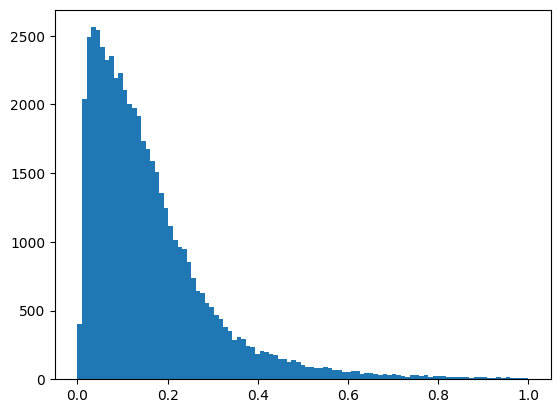

In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.hist(delta.norm(dim=1), bins=np.linspace(0, 1, 100))
plt.show()

## Pre-pool (step 3)

`F.embedding_bag` with a 2D index treats each row as one equal-length bag, fusing the gather and the per-row pool -- the `(n_samples, n_windows, D)` intermediate never materializes. This is the exact tensor the head trains on via `forward_postsum`. Note `mean == sum / n_windows` here (every sample has the same number of windows).

In [ ]:
# summed = F.embedding_bag(sample_fp_index, cache, mode='sum')   # (n_samples, D)
summed = F.embedding_bag(sample_fp_index, delta, mode='mean')   # (n_samples, D)

tr = summed[train_idx]
va = summed[val_idx]

mean = tr.mean(0)
std = tr.std(0)
print(f"'mean'={POOL}")
print(f"  pooled absmax {summed.abs().max():.4g}   per-sample mean-of-dims {summed.mean():.4g}")
print(f"  per-dim across-sample std (train): min {std.min():.4g}  median {std.median():.4g}  max {std.max():.4g}")
print(f"  #dims with std < 1e-5 (the standardizer eps floor): {(std < 1e-5).sum()} / {emb_dim}")

'mean'=mean
  pooled absmax 43.52   per-sample mean-of-dims -7.67e-07
  per-dim across-sample std (train): min 1.856e-05  median 0.2916  max 14.86
  #dims with std < 1e-5 (the standardizer eps floor): 0 / 1024


In [17]:
print(mean)

tensor([3295.0730, 8393.9766,  145.7115,  ..., 3687.7258, -410.0972,
        1489.8777])


In [15]:
tr.std(dim=0)

tensor([0.2190, 0.2562, 0.2609,  ..., 0.7297, 0.1912, 0.2310])

## Standardizer (step 4)

The real `_LearnedStandardizer`, warm-started on the **train** pooled vectors exactly as `train_head.py` does (`--warm-start-standardizer`). It fits `mean = tr.mean(0)` and `scale = tr.std(0).clamp_min(eps)`, then `forward(x) = (x - mean) / scale`. Train z is unit-variance by construction; watch how **val** z behaves -- that's what the head actually has to generalize to.

In [ ]:
std_layer = _LearnedStandardizer(emb_dim)
std_layer.warm_start(tr)

with torch.no_grad():
    ztr = std_layer(tr)
    zva = std_layer(va)

scale = std_layer.log_scale.exp()
n_clamped = (tr.std(0) < std_layer.eps).sum().item()
print(f"standardizer eps={std_layer.eps}  -> {n_clamped}/{emb_dim} dims hit the clamp floor")
print(f"  scale (=clamped std): min {scale.min():.4g}  median {scale.median():.4g}  max {scale.max():.4g}")
print(f"  train z: absmax {ztr.abs().max():.4g}  per-dim std max {ztr.std(0).max():.4g}")
print(f"  val   z: absmax {zva.abs().max():.4g}  per-dim std max {zva.std(0).max():.4g}")
print(f"  cond(train z): {torch.linalg.cond(ztr.double()).item():.4g}")

## Scratch

`cache`, `sample_fp_index`, `summed`, `tr`/`va`, `Y`, `train_idx`/`val_idx`, and `std_layer` are all in scope. Flip `POOL` and re-run from the pre-pool cell to compare sum vs mean, or compare `summed` against a float64 pool to gauge accumulation error:

```python
p64 = F.embedding_bag(sample_fp_index, cache.double(), mode=POOL)
err = (summed.double() - p64).abs()
print("float32 pool error vs signal:", (err[train_idx].median(0).values / tr.std(0)).median())
```